# Crime count regression — results overview

Summary of the experiments run on top of the BRACIS 2024 code (EvolveGCN repo), read from the saved logs (no retraining).
Full notes (in Spanish): `RESULTADOS.md`. Run this notebook from the repo root with the `sfty` conda env.

**Setup in one paragraph.** Each sample predicts next-step crime counts for every street segment. Inputs: static street
features (length, geosampa POI counts within 222 m), a static street graph, and `log1p` counts of the previous steps
(lags). Models: `gcn` (no recurrence), `gruA` (GCN per snapshot + GRU), `egcn_h` (evolving GCN weights). Output:
negative binomial (NB), ZINB or Poisson parameters. *Residual* runs add `log(expanding mean up to t-1)` as an offset,
so the model learns deviations from each street's history. Baselines: per-street historical mean (train-only, or
expanding up to t-1).

**Metrics.** NLL (proper score; lower is better), MAE, AUC/AP from P(y>0), `hit@k` (share of crimes in the top-k% streets
ranked by predicted mean), `hitlen@k` (same, but the selected streets cover k% of total street length), Spearman,
and `calib` = predicted total / observed total.

In [7]:
import glob, json, pickle, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

EGCN = 'BRACIS2024_GNN/evolvegcn/src/EGCN_model'
LOG = f'{EGCN}/log'

LOADER = 'BRACIS2024_GNN/evolvegcn/src/dataloader/data/dataloader_format_data'

# palette: validated categorical slots (blue, orange, aqua); text stays in ink colors
C = {'model': '#2a78d6', 'baseline': '#eb6834', 'observed': '#1baf7a'}
INK, INK2, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({'figure.facecolor': '#fcfcfb', 'axes.facecolor': "#24241c", 'axes.edgecolor': GRID,
                     'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2, 'text.color': INK,
                     'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})

COLS = ['nll', 'mae', 'auc', 'ap', 'spearman', 'hit@0.05', 'hitlen@0.05', 'calib_total_ratio']

def load_grid(folder, cols=COLS):
    """One row per config (mean over seeds) + the baselines stored with the runs."""
    runs = {}
    for f in sorted(glob.glob(f'{LOG}/{folder}/*_test_metrics.json')):
        name = re.sub(r'_s\d+_test_metrics\.json$', '', f.split('/')[-1])
        runs.setdefault(name, []).append(json.load(open(f)))
    rows = {n: {**{c: np.nanmean([r['model'].get(c, np.nan) for r in rs]) for c in cols}, 'seeds': len(rs)}
            for n, rs in runs.items()}
    base = next(iter(runs.values()))[0]['baselines']
    for b, m in base.items():
        rows[f'BASELINE {b}'] = {**{c: m.get(c, np.nan) for c in cols}, 'seeds': 0}
    return pd.DataFrame(rows).T.rename(columns={'calib_total_ratio': 'calib'})

def show(df, sort='nll'):
    return df.sort_values(sort).style.format(precision=3).format({'seeds': '{:.0f}'})

In [2]:
import glob

def ler_logs_classificacao(pasta_logs):
    arquivos_log = glob.glob(f"{pasta_logs}/*.log")
    
    if not arquivos_log:
        print("Nenhum arquivo .log encontrado na pasta.")
        return
        
    for arquivo in sorted(arquivos_log):
        nome = arquivo.split('/')[-1]
        print(f"=== Resumo de {nome} ===")
        
        with open(arquivo, 'r') as f:
            linhas = f.readlines()
            # Puxa as últimas 15 linhas onde o EvolveGCN imprime o teste final
            for linha in linhas[-15:]:
                print(linha.strip())
        print("\n" + "-"*50 + "\n")

# Extrai os resultados dos treinos de classificação
ler_logs_classificacao(LOG)

=== Resumo de log_sp_node_cls_egcn_h_20261008195212_r0.log ===
'seed': 1234,
'smart_neg_sampling': False,
'sp_args': <utils.Namespace object at 0x7f2083afb9d0>,
'steps_accum_gradients': 1,
'target_class': 1,
'target_measure': 'F1',
'task': 'node_cls',
'train_proportion': 0.75,
'use_1_hot_node_feats': False,
'use_2_hot_node_feats': False,
'use_cuda': False,
'use_logfile': True,
'wsize': 1}
INFO:root:
INFO:root:################ TRAIN epoch 0 ###################

--------------------------------------------------

=== Resumo de log_sp_node_cls_egcn_h_20261008195226_r0.log ===
'seed': 1234,
'smart_neg_sampling': False,
'sp_args': <utils.Namespace object at 0x7f2da8eef9d0>,
'steps_accum_gradients': 1,
'target_class': 1,
'target_measure': 'F1',
'task': 'node_cls',
'train_proportion': 0.75,
'use_1_hot_node_feats': False,
'use_2_hot_node_feats': False,
'use_cuda': False,
'use_logfile': True,
'wsize': 1}
INFO:root:
INFO:root:################ TRAIN epoch 0 ###################

------------------

## 1. Resultados da Classificação de Nós (EvolveGCN)

Comparativo de desempenho do modelo `egcn_h` utilizando diferentes partições espaciais (K-means, CEP, Correlação). A métrica principal de avaliação é o **F1-Score da Classe 1** (ruas de alto risco criminal), evidenciando o impacto direto da topologia do grafo na capacidade de generalização da GNN. Resultados com F1 perfeito (1.0) foram isolados por representarem overfitting devido a partições que descaracterizam a conectividade urbana.

In [4]:

# show(load_grid('reg_grid_M'))
def extrair_metricas_logs(pasta_logs):
    arquivos_log = glob.glob(f"{pasta_logs}/*.log")
    linhas_df = []

    for arquivo in sorted(arquivos_log):
        # Limpa o nome do arquivo para manter apenas o identificador da rodada
        nome = arquivo.split('/')[-1].replace('.log', '').replace('log_sp_node_cls_egcn_h_', '')
        
        f1_micro, f1_class1 = None, None
        
        with open(arquivo, 'r') as f:
            conteudo = f.read()
            
            # Captura a última métrica Micro Average registrada
            match_micro = re.findall(r'VALID measures microavg - precision [\d\.]+ - recall [\d\.]+ - f1 ([\d\.]+)', conteudo)
            if match_micro:
                f1_micro = float(match_micro[-1])
                
            # Captura a última métrica específica da Classe 1 (Geralmente a classe de alto risco)
            match_c1 = re.findall(r'VALID measures for class 1 - precision [\d\.]+ - recall [\d\.]+ - f1 ([\d\.]+)', conteudo)
            if match_c1:
                f1_class1 = float(match_c1[-1])
                
        # Só adiciona se encontrou métricas de avaliação no log
        if f1_micro or f1_class1:
            linhas_df.append({
                'Experimento': nome,
                'F1 (Micro)': f1_micro,
                'F1 (Classe 1)': f1_class1
            })
        
    df = pd.DataFrame(linhas_df)
    return df.sort_values(by='F1 (Classe 1)', ascending=False).reset_index(drop=True)



In [5]:
# Extrai as métricas finais (F1-score) dos logs de classificação recém-gerados
df_resultados = extrair_metricas_logs(LOG)

# Renderiza a tabela destacando os maiores valores de F1 da Classe 1
display(df_resultados.style.format(precision=4).background_gradient(subset=['F1 (Classe 1)'], cmap='viridis'))

,Experimento,F1 (Micro),F1 (Classe 1)
0,20261009125654_r0,1.0000,1.0000
1,20261009130024_r0,1.0000,1.0000
2,20261009125407_r0,0.9537,0.9763
3,20261009125811_r0,0.8754,0.9336
4,20261009125219_r0,0.8274,0.9056
5,20261009125114_r0,0.7553,0.8606
6,20261009120455_r0,0.4282,0.4995
7,20261009092210_r0,0.4118,0.4941
8,20261008203726_r0,0.3020,0.4638
9,20261008195436_r0,0.3020,0.4638


/tmp/ipykernel_10262/3263221240.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


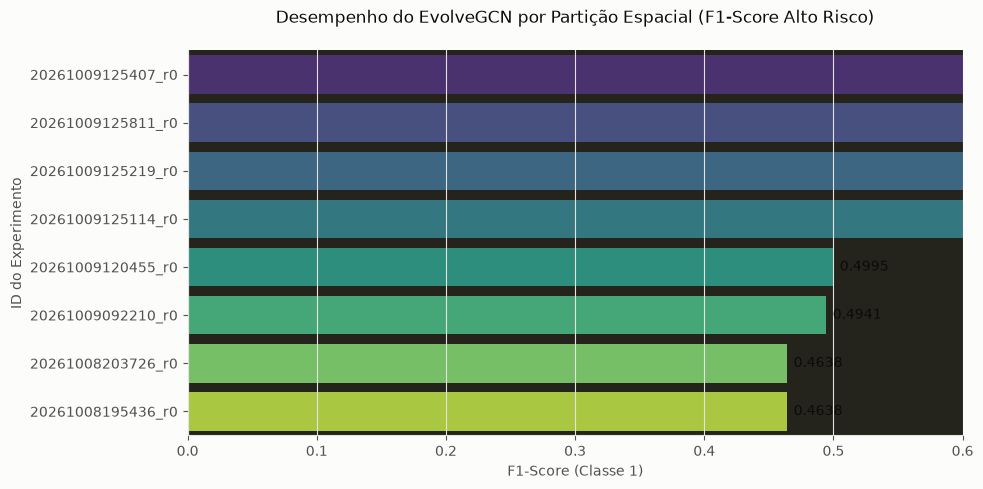

In [8]:
plt.figure(figsize=(10, 5))

# Filtra os edge cases (F1 > 0.99) e ordena para visualização
df_plot = df_resultados[df_resultados['F1 (Classe 1)'] < 0.99].sort_values('F1 (Classe 1)', ascending=False)

ax = sns.barplot(
    data=df_plot, 
    y='Experimento', 
    x='F1 (Classe 1)', 
    palette='viridis'
)

plt.title('Desempenho do EvolveGCN por Partição Espacial (F1-Score Alto Risco)', pad=20)
plt.xlabel('F1-Score (Classe 1)')
plt.ylabel('ID do Experimento')
plt.xlim(0, 0.6)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points',
                color=INK)

plt.show()

/tmp/ipykernel_10262/268878337.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


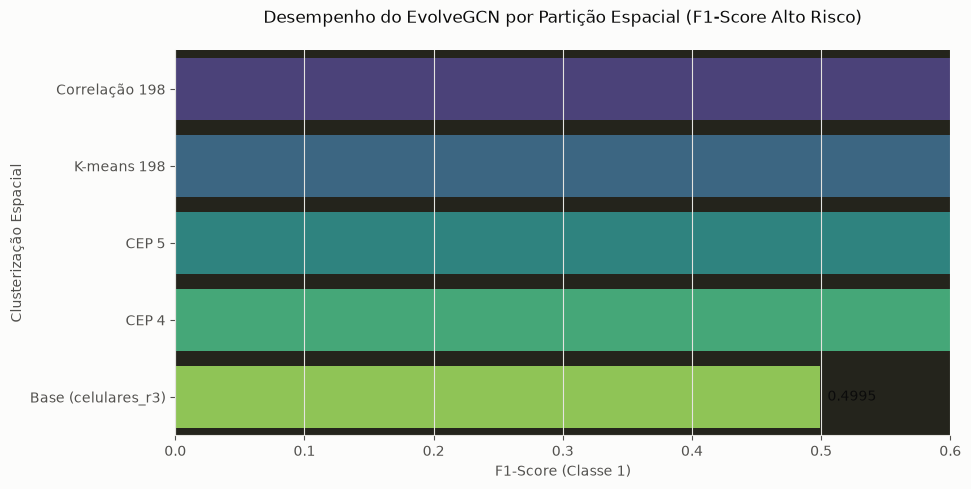

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dicionário extraído da ordem de execução do Grid Search no terminal
mapeamento_particoes = {
    '20261009120455_r0': 'Base (celulares_r3)',
    '20261009125114_r0': 'CEP 4',
    '20261009125219_r0': 'CEP 5',
    '20261009125407_r0': 'Correlação 198',
    '20261009125654_r0': 'Correlação 47',
    '20261009125811_r0': 'K-means 198',
    '20261009130024_r0': 'K-means 47',
    # Logs antigos descartados da visualização final
    '20261009092210_r0': 'Descartado',
    '20261008203726_r0': 'Descartado',
    '20261008195436_r0': 'Descartado'
}

# 2. Aplica o mapeamento criando uma nova coluna
df_resultados['Partição'] = df_resultados['Experimento'].map(mapeamento_particoes).fillna(df_resultados['Experimento'])

# 3. Filtra as rodadas descartadas e os casos de overfitting (F1 > 0.99)
df_plot = df_resultados[
    (df_resultados['Partição'] != 'Descartado') & 
    (df_resultados['F1 (Classe 1)'] < 0.99)
].sort_values('F1 (Classe 1)', ascending=False)

# 4. Renderiza o gráfico
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_plot, 
    y='Partição', 
    x='F1 (Classe 1)', 
    palette='viridis'
)

plt.title('Desempenho do EvolveGCN por Partição Espacial (F1-Score Alto Risco)', pad=20)
plt.xlabel('F1-Score (Classe 1)')
plt.ylabel('Clusterização Espacial')
plt.xlim(0, 0.6) # Mantendo o limite que ajusta bem a leitura dos rótulos

for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points')

plt.show()

## 2. New data (phone thefts 2022–2025, 2100-street graph), monthly

Robbery + theft, one row per police report, central SP. Date split: train ≤ 2024-06, validation 2024-H2,
test = 12 months of 2025. Central SP had a ~40% drop in 2024–25, so the train-period mean over-predicts 2025.
**With the residual offset, models beat the expanding mean on every metric; without it they lose.**

In [3]:
r3 = load_grid('reg_grid_r3_sp_r3_M')
show(r3)

StopIteration: 

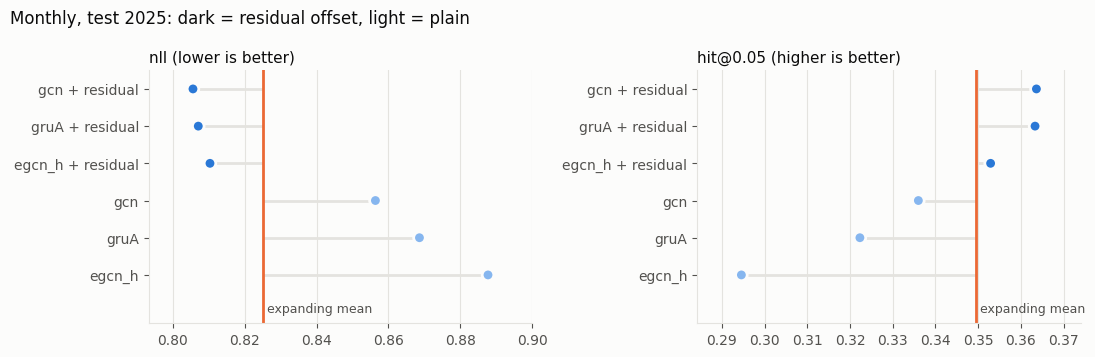

In [4]:
# NLL and hit@5% per config vs the expanding-mean baseline (one measure per chart: no shared axis)
d = r3[r3.index.str.contains('_nb')].copy()
d.index = d.index.str.replace('node_reg_', '').str.replace('_lag3_nb', '').str.replace('_res', ' + residual')
base = r3.loc['BASELINE hist_mean_expanding']
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col, better in [(axes[0], 'nll', 'lower is better'), (axes[1], 'hit@0.05', 'higher is better')]:
    s = d[col].sort_values(ascending=(col != 'nll'))
    # dots, not bars: the axis does not start at zero
    ax.hlines(s.index, base[col], s.values, color=GRID, lw=2)
    ax.scatter(s.values, s.index, s=70, zorder=3, edgecolor='#fcfcfb', linewidth=2,
               color=[C['model'] if 'residual' in i else '#86b6ef' for i in s.index])
    ax.axvline(base[col], color=C['baseline'], lw=2)
    ax.text(base[col], -0.9, ' expanding mean', color=INK2, va='center', fontsize=9)
    ax.set_ylim(-1.3, len(s) - 0.5)
    lo = min(s.min(), base[col]); hi = max(s.max(), base[col])
    ax.set_xlim(lo - 0.15 * (hi - lo), hi + 0.15 * (hi - lo))
    ax.set_title(f'{col} ({better})', loc='left', fontsize=11)
    ax.grid(axis='y', visible=False)
fig.suptitle('Monthly, test 2025: dark = residual offset, light = plain', x=0.01, ha='left', fontsize=12)
plt.tight_layout()

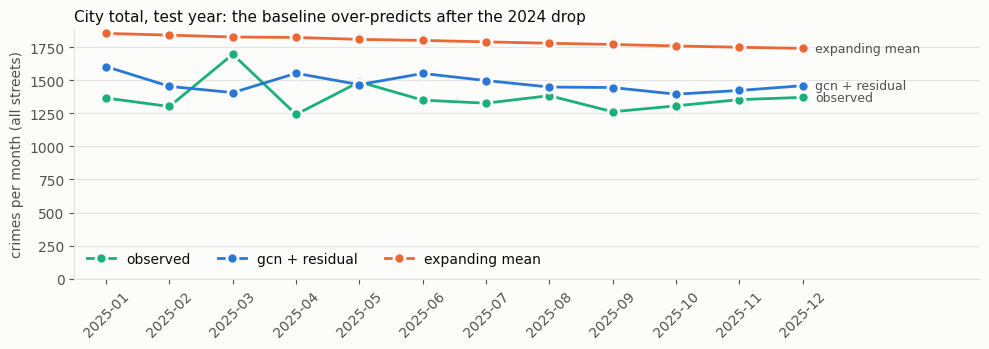

In [5]:
# City-wide monthly total in 2025: observed vs gcn residual (seed 1) vs expanding mean
import torch, sys
sys.path.insert(0, EGCN)
import count_reg as cr
c = pickle.load(open(f'{LOADER}/sp_r3/nodes_counts_times-M.pickle', 'rb'))
Y = np.zeros((c[:, 2].max() + 1, c[:, 0].max() + 1)); Y[c[:, 2], c[:, 0]] = c[:, 1]
periods = pickle.load(open(f'{LOADER}/sp_r3/periods-M.pickle', 'rb'))
z = np.load(f'{LOG}/reg_grid_r3_sp_r3_M/node_reg_gcn_lag3_nb_res_s1_test_preds.npz')
em = cr.expanding_log_mean(torch.from_numpy(Y)).exp().numpy()
x = [periods[t] for t in z['steps']]
fig, ax = plt.subplots(figsize=(10, 3.6))
for key, vals, label in [('observed', z['y'].sum(1), 'observed'), ('model', z['mu'].sum(1), 'gcn + residual'),
                         ('baseline', em[z['steps']].sum(1), 'expanding mean')]:
    ax.plot(x, vals, color=C[key], lw=2, marker='o', ms=8, mec='#fcfcfb', mew=2, label=label)
    ax.text(len(x) - 0.8, vals[-1], label, color=INK2, va='center', fontsize=9)
ax.set_xlim(-0.5, len(x) + 1.8); ax.set_ylim(0, None); ax.set_ylabel('crimes per month (all streets)')
ax.legend(frameon=False, loc='lower left', ncol=3)
ax.set_title('City total, test year: the baseline over-predicts after the 2024 drop', loc='left', fontsize=11)
ax.tick_params(axis='x', rotation=45); ax.grid(axis='x', visible=False)
plt.tight_layout()

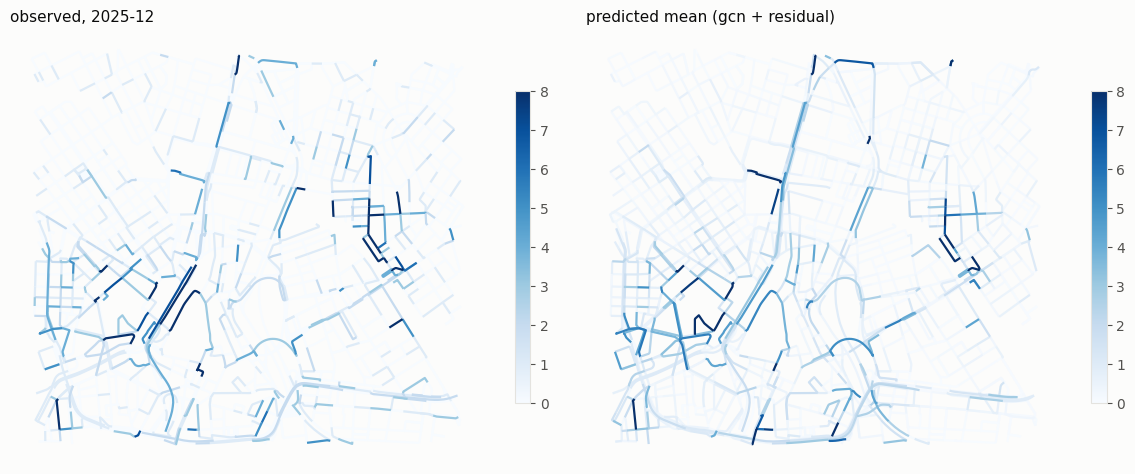

In [6]:
# Street map, last test month: observed vs predicted (same sequential scale)
import geopandas as gpd
streets = pickle.load(open('crime-data/data/processed/sp/celulares_r3/street_nodes_dataframe.pickle', 'rb'))
vmax = np.quantile(z['y'][-1], 0.99)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, vals, title in [(axes[0], z['y'][-1], f'observed, {x[-1]}'), (axes[1], z['mu'][-1], 'predicted mean (gcn + residual)')]:
    streets.assign(v=np.minimum(vals, vmax)).sort_values('v').plot(column='v', ax=ax, cmap='Blues', vmin=0, vmax=vmax,
                                                                  linewidth=1.6, legend=True, legend_kwds={'shrink': 0.6})
    ax.set_title(title, loc='left', fontsize=11); ax.set_axis_off()
plt.tight_layout()

## 3. Weekly (same data), 1 seed

Same pattern as monthly: the residual offset wins; `gcn` ≈ `gruA`.

In [7]:
show(load_grid('reg_grid_r3_sp_r3_W'))

/tmp/ipykernel_2826025/340832986.py:24: RuntimeWarning: Mean of empty slice
  rows = {n: {**{c: np.nanmean([r['model'].get(c, np.nan) for r in rs]) for c in cols}, 'seeds': len(rs)}


,nll,mae,auc,ap,spearman,hit@0.05,hitlen@0.05,calib,seeds
node_reg_gruA_lag3_nb_res,0.341965,0.194007,0.829776,0.429010,0.356121,0.362675,0.356319,0.892716,1
node_reg_gcn_lag3_nb_res,0.343027,0.192521,0.829984,0.431251,0.356267,0.366915,0.355718,0.876990,1
BASELINE hist_mean_expanding,0.350328,0.229298,0.825344,0.409690,nan,0.347413,nan,1.299438,0
node_reg_gruA_lag3_nb,0.354104,0.206702,0.806515,0.400479,0.331366,0.351424,0.325471,0.922125,1
node_reg_gcn_lag3_nb,0.355229,0.215724,0.807808,0.397004,0.332890,0.345870,0.317067,1.035470,1
node_reg_egcn_h_lag3_nb,0.365385,0.209693,0.787213,0.364328,nan,0.323988,nan,0.891257,1
BASELINE hist_mean_train,0.365555,0.244673,0.813573,0.383644,nan,0.305798,nan,1.421388,0


## 4. History length, shuffle and calendar features

* Monthly, 3 seeds, training from t=12: shuffling makes no difference; a 12-month history (12 lags, or 12 snapshots)
  is slightly worse.
* Weekly, 1 seed, training from week 8: an 8-week history and sin/cos calendar features (time of year, position in
  month) stay within noise (±0.002 NLL). The model looks saturated on what past counts can give.

In [8]:
show(load_grid('reg_grid_r3win_sp_r3_M'))

,nll,mae,auc,ap,spearman,hit@0.05,hitlen@0.05,calib,seeds
node_reg_gcn_lag3_nb_res_h5_shuf,0.801943,0.578899,0.837071,0.715187,0.559538,0.367509,0.351487,1.003115,3
node_reg_gcn_lag3_nb_res_h5,0.802092,0.570776,0.837183,0.715702,0.559614,0.366613,0.352163,0.963073,3
node_reg_gruA_lag3_nb_res_h5,0.804070,0.581076,0.836833,0.714153,0.559104,0.366389,0.348975,0.998805,3
node_reg_gruA_lag3_nb_res_h5_shuf,0.805755,0.573291,0.837010,0.714874,0.559416,0.365787,0.350468,0.957130,3
node_reg_gcn_lag12_nb_res_h5_shuf,0.806382,0.620725,0.836093,0.713030,0.557945,0.358086,0.350961,1.165888,3
node_reg_gruA_lag12_nb_res_h5_shuf,0.806609,0.611440,0.836306,0.713412,0.558216,0.357072,0.350840,1.110281,3
node_reg_gruA_lag3_nb_res_h12_shuf,0.808440,0.618335,0.835630,0.711142,0.557338,0.360315,0.347234,1.143107,3
BASELINE hist_mean_expanding,0.825206,0.683713,0.833169,0.702083,0.553976,0.349452,0.334947,1.310284,0
BASELINE hist_mean_train,0.878860,0.757327,0.821656,0.678951,0.535324,0.309345,0.307471,1.428509,0


In [9]:
show(load_grid('reg_grid_r3winW_sp_r3_W'))

,nll,mae,auc,ap,spearman,hit@0.05,hitlen@0.05,calib,seeds
node_reg_gruA_lag1_nb_res_h8,0.341920,0.203117,0.827935,0.423216,0.354187,0.356754,0.350704,1.005629,1
node_reg_gruA_lag1_nb_res_h8_time,0.342500,0.192358,0.829254,0.427822,0.356027,0.363230,0.357531,0.885585,1
node_reg_gcn_lag3_nb_res_h5_time,0.342612,0.202557,0.827893,0.422841,0.354371,0.358706,0.351832,1.004635,1
node_reg_gcn_lag8_nb_res_h5,0.343107,0.194889,0.829646,0.427687,0.355716,0.359488,0.351451,0.896667,1
node_reg_gcn_lag3_nb_res_h5,0.343544,0.191335,0.830116,0.432832,0.356390,0.367369,0.354180,0.860965,1
node_reg_gruA_lag3_nb_res_h5,0.343862,0.193515,0.829959,0.429026,0.356055,0.362094,0.352645,0.876519,1
node_reg_gcn_lag8_nb_res_h5_time,0.345087,0.199111,0.828084,0.419722,0.354453,0.353550,0.345101,0.942690,1
BASELINE hist_mean_expanding,0.350328,0.229298,0.825344,0.409690,0.351820,0.347413,0.334399,1.299438,0
BASELINE hist_mean_train,0.365555,0.244673,0.813573,0.383644,0.339290,0.305798,0.304910,1.421388,0


## 5. Hypernodes

Partitions with K matched to CEP resolution (47 = CEP 4 digits, 198 = CEP 5 digits): KMeans on centroids, majority
CEP prefix, and spectral clustering on weekly train correlations (latent). Within each partition, on the same 2025
months: street-level model predictions **summed** to hypernodes vs the same model trained **directly** on hypernodes,
vs the hypernode expanding mean. Absolute values are not comparable across K; compare gains over each partition's
baseline.

**Training on hypernodes does not beat summing street-level predictions** (worse at K=47, tie at K=198).
Correlation clusters rank worst and their within-cluster correlation collapses out of sample (train 0.07–0.09 →
2025 0.004–0.007, below geographic clusters). On hypernodes 75–100% of unit-months are positive, so only regression
makes sense.

In [10]:
lines = [l for l in open(f'{LOG}/hypernodes_M.md') if l.startswith('|') and not l.startswith('|---')]
rows = [[c.strip() for c in l.strip().strip('|').split('|')] for l in lines]
hyp = pd.DataFrame(rows[1:], columns=rows[0])
hyp.columns = ['partition', 'K', 'source'] + list(hyp.columns[3:])
num = lambda s: pd.to_numeric(s.str.split(' ').str[0].str.replace('–', 'nan').str.replace('%', ''), errors='coerce')
for col in hyp.columns[3:]:
    hyp[col] = num(hyp[col])
hyp.rename(columns={hyp.columns[-1]: 'MAE gain vs baseline (%)'})

,partition,K,source,nll,mae,rmse,spearman,hitlen@0.05,hitlen@0.1,auc,calib_total_ratio,MAE gain vs baseline (%)
0,street,2100,baseline calles agregado,NaN,0.684,1.505,0.554,0.335,0.484,0.833,1.310,0.0
1,street,2100,gcn calles agregado,NaN,0.595,1.369,0.559,0.351,0.493,0.837,1.075,12.9
2,street,2100,gruA calles agregado,NaN,0.607,1.382,0.558,0.353,0.492,0.836,1.120,11.3
3,kmeans47,47,baseline hipernodo,3.754,14.469,23.231,0.888,0.098,0.198,0.801,1.310,0.0
4,kmeans47,47,baseline calles agregado,NaN,14.489,23.268,0.887,0.098,0.197,0.803,1.310,-0.1
5,kmeans47,47,gcn calles agregado,NaN,9.184,14.777,0.914,0.094,0.217,0.823,1.075,36.5
6,kmeans47,47,gcn directo en hipernodos,3.644,10.831,17.689,0.900,0.100,0.201,0.793,1.140,25.1
7,kmeans47,47,gruA calles agregado,NaN,9.833,15.650,0.914,0.095,0.222,0.814,1.120,32.0
8,kmeans47,47,gruA directo en hipernodos,3.619,10.350,17.263,0.899,0.101,0.217,0.796,1.066,28.5
9,cep4,47,baseline hipernodo,3.052,13.141,24.441,0.927,0.110,0.181,0.948,1.310,0.0


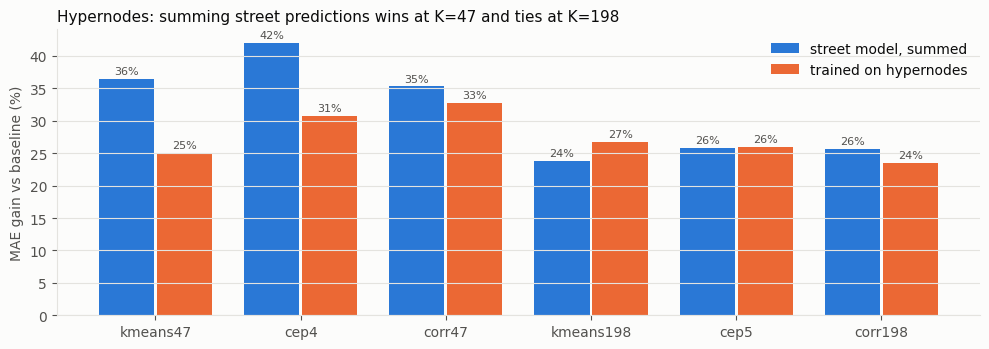

In [11]:
# MAE gain over the partition's own baseline: street model summed vs trained directly on hypernodes (gcn)
g = hyp[hyp.source.str.startswith('gcn') & (hyp.partition != 'street')].copy()
g['how'] = np.where(g.source.str.contains('directo'), 'trained on hypernodes', 'street model, summed')
p = g.pivot(index='partition', columns='how', values=hyp.columns[-1]).loc[['kmeans47', 'cep4', 'corr47', 'kmeans198', 'cep5', 'corr198']]
fig, ax = plt.subplots(figsize=(10, 3.6))
w = 0.38; xs = np.arange(len(p))
for i, (col, color) in enumerate([('street model, summed', C['model']), ('trained on hypernodes', C['baseline'])]):
    bars = ax.bar(xs + (i - 0.5) * (w + 0.02), p[col], width=w, color=color, label=col)
    ax.bar_label(bars, fmt='%.0f%%', color=INK2, fontsize=8, padding=2)
ax.set_xticks(xs, p.index); ax.set_ylabel('MAE gain vs baseline (%)'); ax.grid(axis='x', visible=False)
ax.legend(frameon=False, loc='upper right')
ax.set_title('Hypernodes: summing street predictions wins at K=47 and ties at K=198', loc='left', fontsize=11)
plt.tight_layout()

## Takeaways

1. The original setup fed only static inputs, so the GNNs produced a static risk map; the per-street historical mean beat it.
2. Count regression with an overdispersed likelihood (NB; ZINB adds nothing detectable) and a **residual offset on the
   expanding mean** is the only configuration that beats the historical baseline — partly by tracking the 2024 level
   drop, partly by better ranking (hit@5% 0.350 → 0.364 monthly, 11/12 test months).
3. Recurrence (`gruA`, `egcn_h`) adds nothing over `gcn` + 3 lags; longer windows, shuffling and calendar features do not help.
4. Hypernodes: aggregate street-level predictions instead of training on groups; geographic groups beat correlation-based ones.

Caveats: one test year; few seeds on weekly runs.